# Day 08. Exercise 03
# Overfitting

## 0. Imports

In [213]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib

## 1. Preprocessing

1. Read the file `dayofweek.csv` to a dataframe.
2. Using `train_test_split` with parameters `test_size=0.2`, `random_state=21` get `X_train`, `y_train`, `X_test`, `y_test`.
3. Using, for example, `value_counts()` to check if the distribution of classes is similar in train and test.
4. Use the additional parameter `stratify=` and check the distribution again, now it should be more or less similar in both datasets.

In [214]:
df = pd.read_csv('data/dayofweek.csv')

print(df.shape)
df.head()

(1686, 44)


,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,-0.788667,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.756764,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.724861,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.692958,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.661055,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [215]:
X = df.drop('dayofweek', axis=1)
y = df['dayofweek']

print(f"X (размер): {X.shape}")
print(f"y (размер): {y.shape}")

X (размер): (1686, 43)
y (размер): (1686,)


In [216]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=21
)

print("Train/test split без стратификации:")
print(f"X_train (размер): {X_train.shape}")
print(f"X_test (размер): {X_test.shape}")
print("\nТренировочный набор:")
print(pd.Series(y_train).value_counts().sort_index())
print("\nТестовый набор:")
print(pd.Series(y_test).value_counts().sort_index())

Train/test split без стратификации:
X_train (размер): (1348, 43)
X_test (размер): (338, 43)

Тренировочный набор:
dayofweek
0    105
1    222
2    125
3    313
4     80
5    216
6    287
Name: count, dtype: int64

Тестовый набор:
dayofweek
0    31
1    52
2    24
3    83
4    24
5    55
6    69
Name: count, dtype: int64


In [217]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=21, stratify=y
)

print("Train/test split со стратификацией")
print(f"X_train (размер): {X_train.shape}")
print(f"X_test (размер): {X_test.shape}")
print("\nТренировочный набор:")
print(pd.Series(y_train).value_counts().sort_index())
print("\nТестовый набор:")
print(pd.Series(y_test).value_counts().sort_index())

Train/test split со стратификацией
X_train (размер): (1348, 43)
X_test (размер): (338, 43)

Тренировочный набор:
dayofweek
0    109
1    219
2    119
3    316
4     83
5    217
6    285
Name: count, dtype: int64

Тестовый набор:
dayofweek
0    27
1    55
2    30
3    80
4    21
5    54
6    71
Name: count, dtype: int64


## 2. Baseline models

1. Train exactly the same baseline models from the previous exercise and calculate the accuracies using the test dataset with stratification.
2. Did all the models show the similar values of the metric? Which one has the largest difference comparing the current exercise and the previous? Put the answer to the markdown cell in the end of the section.

### a. Logreg

In [218]:
logreg = LogisticRegression(random_state=21, fit_intercept=False).fit(X_train, y_train)

test_acc_lr = accuracy_score(y_test, logreg.predict(X_test))

print(f"Логистическая регрессия:")
print(f"Аccuracy (тестовая выборка):  {test_acc_lr}")
print(f"Accuracy (задание 02):  0.6405693950177936")

Логистическая регрессия:
Аccuracy (тестовая выборка):  0.6331360946745562
Accuracy (задание 02):  0.6405693950177936


### b. SVM

In [219]:
svc = SVC(kernel='linear', probability=True, random_state=21).fit(X_train, y_train)

test_acc_svc = accuracy_score(y_test, svc.predict(X_test))

print(f"SVM (linear kernel):")
print(f"Аccuracy (тестовая выборка):  {test_acc_svc}")
print(f"Accuracy (задание 02):  0.702846975088968")

SVM (linear kernel):
Аccuracy (тестовая выборка):  0.7159763313609467
Accuracy (задание 02):  0.702846975088968


### c. Decision tree

In [220]:
dt = DecisionTreeClassifier(max_depth=4, random_state=21).fit(X_train, y_train)

test_acc_dt = accuracy_score(y_test, dt.predict(X_test))

print(f"Decision Tree (max_depth=4):")
print(f"Аccuracy (тестовая выборка):  {test_acc_dt}")
print(f"Accuracy (задание 02):  0.5516014234875445")

Decision Tree (max_depth=4):
Аccuracy (тестовая выборка):  0.5295857988165681
Accuracy (задание 02):  0.5516014234875445


### d. Random forest

In [221]:
rf = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21).fit(X_train, y_train)

test_acc_rf = accuracy_score(y_test, rf.predict(X_test))

print(f"Random Forest (n_estimators=100, max_depth=25):")
print(f"Аccuracy (тестовая выборка):  {test_acc_rf}")
print(f"Accuracy (задание 02):  1.0")

Random Forest (n_estimators=100, max_depth=25):
Аccuracy (тестовая выборка):  0.9289940828402367
Accuracy (задание 02):  1.0


**Можно видеть, что во всех случаях, не считая SVC, при работе с тестовой выборкой accuracy падает по сравнению с результатами оценок в прошлом задании. Лучше всего справляется случайный лес (Random Forest). У него же наблюдается наиболее падение в accuracy по сравнению с предыдущим заданием.**

## 3. Crossvalidation

We could play with parameters of the model trying to achive a better accuracy on the test dataset, but it is a bad practice. It leads us again to overfitting. Test dataset is only for checking quality of a final model.

But there is another way of solving the problem – crossvalidation. It does not use test dataset, but creates one more split of train dataset. Again, there are different ways of doing it, but the common thing is that there is a validation dataset that is used for hyperparameters optimization.

1. Using `cross_val_score` with `cv=10` calculate the mean accuracy and standard deviation for every model that you used before (logreg with `solver='liblinear'`, SVC, decision tree, random forest).

### a. Logreg

In [222]:
lr_cv = LogisticRegression(random_state=21, fit_intercept=False, max_iter=1000, solver='liblinear')
cv_scores_lr = cross_val_score(OneVsRestClassifier(lr_cv), X_train, y_train, cv=10, scoring='accuracy')

print(f"Логистическая регрессия - кросс-валидация (cv=10):")
print(f"Значения accuracy: {cv_scores_lr}")
print(f"Среднее accuracy: {cv_scores_lr.mean()}")
print(f"Стандартное отклонение accuracy: {cv_scores_lr.std()}")

Логистическая регрессия - кросс-валидация (cv=10):
Значения accuracy: [0.56296296 0.61481481 0.59259259 0.60740741 0.55555556 0.57777778
 0.61481481 0.53333333 0.58208955 0.57462687]
Среднее accuracy: 0.5815975677169707
Стандартное отклонение accuracy: 0.025322132907253592


### b. SVM

In [223]:
svc_cv = SVC(kernel='linear', probability=True, random_state=21)
cv_scores_svc = cross_val_score(svc_cv, X_train, y_train, cv=10, scoring='accuracy')

print(f"SVM (linear) - кросс-валидация (cv=10):")
print(f"Значения accuracy: {cv_scores_svc}")
print(f"Среднее accuracy: {cv_scores_svc.mean()}")
print(f"Стандартное отклонение accuracy: {cv_scores_svc.std()}")

SVM (linear) - кросс-валидация (cv=10):
Значения accuracy: [0.65925926 0.75555556 0.62222222 0.65185185 0.65185185 0.64444444
 0.72592593 0.62222222 0.61940299 0.63432836]
Среднее accuracy: 0.6587064676616916
Стандартное отклонение accuracy: 0.043585708770590564


### c. Decision tree

In [224]:
dt_cv = DecisionTreeClassifier(max_depth=4, random_state=21)
cv_scores_dt = cross_val_score(dt_cv, X_train, y_train, cv=10, scoring='accuracy')

print(f"Decision Tree (max_depth=4) - кросс-валидация (cv=10):")
print(f"Значения accuracy: {cv_scores_dt}")
print(f"Среднее accuracy: {cv_scores_dt.mean()}")
print(f"Стандартное отклонение accuracy: {cv_scores_dt.std()}")

Decision Tree (max_depth=4) - кросс-валидация (cv=10):
Значения accuracy: [0.48148148 0.52592593 0.47407407 0.52592593 0.57037037 0.51111111
 0.5037037  0.48888889 0.54477612 0.46268657]
Среднее accuracy: 0.5088944168048645
Стандартное отклонение accuracy: 0.031903139495514356


### d. Random forest

In [225]:
rf_cv = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
cv_scores_rf = cross_val_score(rf_cv, X_train, y_train, cv=10, scoring='accuracy')

print(f"Random Forest - кросс-валидация (cv=10):")
print(f"Значения accuracy: {cv_scores_rf}")
print(f"Среднее: {cv_scores_rf.mean()}")
print(f"Стандартное отклонение: {cv_scores_rf.std()}")

Random Forest - кросс-валидация (cv=10):
Значения accuracy: [0.9037037  0.96296296 0.8962963  0.94074074 0.91851852 0.8962963
 0.92592593 0.8962963  0.93283582 0.90298507]
Среднее: 0.9176561636263129
Стандартное отклонение: 0.02159583796321821


## 4. Optimization

1. Choose the best model and play a little bit with the parameters on cross-validation, find a good enough parameter or a combination of the parameters.
2. Calculate the accuracy for the final model on the test dataset.
3. Draw a plot that displays the top-10 most  important features for that model.
4. Save the model using `joblib`.
5. Load the model, make predictions for the test dataset and calculate the accuracy.

In [226]:
print("Оптимизация параметров Random Forest (лучшей модели)")
print("-" * 50)

best_rf_cv_score = 0
best_rf_params = {}
rf_results = {}

for max_depth in [5, 10, 15, 20, 25]:
    for n_est in [50, 100, 150, 200]:
        rf_test = RandomForestClassifier(n_estimators=n_est, max_depth=max_depth, random_state=21)
        cv_scores = cross_val_score(rf_test, X_train, y_train, cv=10, scoring='accuracy')
        cv_mean = cv_scores.mean()
        
        key = (max_depth, n_est)
        rf_results[key] = cv_mean
        
        if cv_mean > best_rf_cv_score:
            best_rf_cv_score = cv_mean
            best_rf_params = {'max_depth': max_depth, 'n_estimators': n_est}
        
        print(f"max_depth={max_depth}, n_est={n_est}: {cv_mean}")

print(f"\nЛучшие параметры: {best_rf_params}")
print(f"CV Score: {best_rf_cv_score}")
print("-" * 50)

Оптимизация параметров Random Forest (лучшей модели)
--------------------------------------------------
max_depth=5, n_est=50: 0.576384742951907
max_depth=5, n_est=100: 0.5764234383637369
max_depth=5, n_est=150: 0.583084577114428
max_depth=5, n_est=200: 0.5756550580431179
max_depth=10, n_est=50: 0.7952294085129906
max_depth=10, n_est=100: 0.8019071310116086
max_depth=10, n_est=150: 0.8056274184632393
max_depth=10, n_est=200: 0.8108181315644002
max_depth=15, n_est=50: 0.8901824212271974
max_depth=15, n_est=100: 0.8961249309010503
max_depth=15, n_est=150: 0.8961083471531233
max_depth=15, n_est=200: 0.8946323935876175
max_depth=20, n_est=50: 0.9087396351575455
max_depth=20, n_est=100: 0.9102266445550027
max_depth=20, n_est=150: 0.909485903814262
max_depth=20, n_est=200: 0.9131951354339414
max_depth=25, n_est=50: 0.9146876727473743
max_depth=25, n_est=100: 0.9176561636263129
max_depth=25, n_est=150: 0.9161636263128801
max_depth=25, n_est=200: 0.916915422885572

Лучшие параметры: {'max_dept

In [227]:
best_rf_final = RandomForestClassifier(n_estimators=best_rf_params['n_estimators'],
                                       max_depth=best_rf_params['max_depth'],
                                       random_state=21
).fit(X_train, y_train)

y_test_pred_best = best_rf_final.predict(X_test)

test_acc_best = accuracy_score(y_test, y_test_pred_best)

print(f"Финальная модель (Random Forest с оптимизированными параметрами):")
print(f"Параметры: {best_rf_params}")
print(f"Средняя accuracy по результатам кросс-валидации: {best_rf_cv_score}")
print(f"Accuracy на тестовом датасете: {test_acc_best}")

Финальная модель (Random Forest с оптимизированными параметрами):
Параметры: {'max_depth': 25, 'n_estimators': 100}
Средняя accuracy по результатам кросс-валидации: 0.9176561636263129
Accuracy на тестовом датасете: 0.9289940828402367


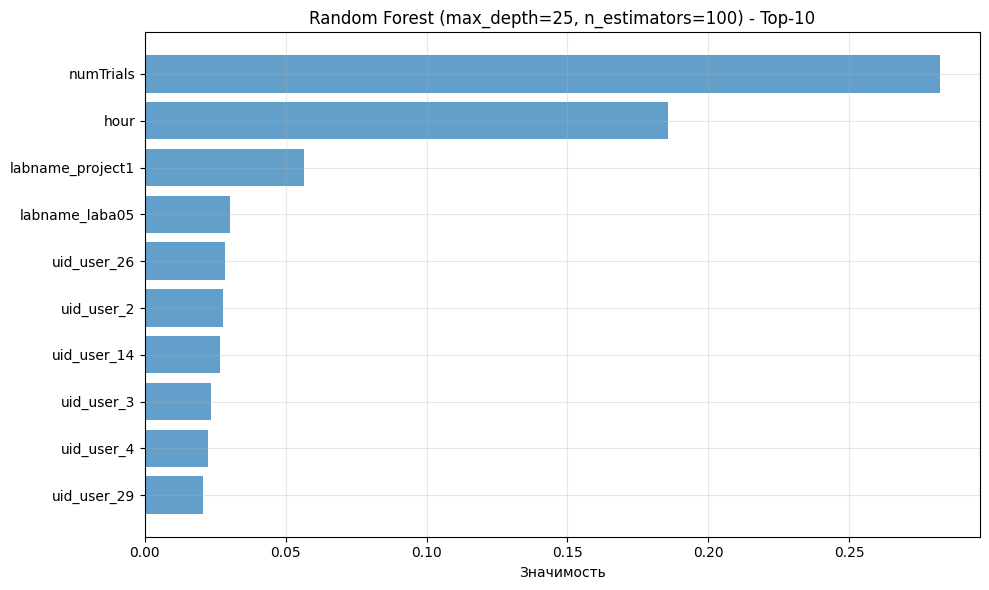

In [228]:
feature_names = [c for c in df.columns if c != 'dayofweek']
best_importances = best_rf_final.feature_importances_

top_n = 10
title = f"Random Forest (max_depth={best_rf_params['max_depth']}, n_estimators={best_rf_params['n_estimators']}) - Top-10"

top_idx = np.argsort(best_importances)[-top_n:][::-1]
values = best_importances[top_idx]
names = [feature_names[i] for i in top_idx]

plt.figure(figsize=(10, 6))
plt.barh(range(top_n), values, alpha=0.7)
plt.yticks(range(top_n), names)
plt.gca().invert_yaxis()
plt.xlabel('Значимость')
plt.title(title)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [229]:
model_filename = 'data/best_rf_model.pkl'
joblib.dump(best_rf_final, model_filename)

['data/best_rf_model.pkl']

In [230]:
loaded_model = joblib.load(model_filename)

In [231]:
y_test_pred_loaded = loaded_model.predict(X_test)

test_acc_loaded = accuracy_score(y_test, y_test_pred_loaded)

print(f"Предсказания с загруженной моделью:")
print(f"Accuracy тестовой выборки: {test_acc_loaded}")
print(f"Совпадает с оригинальной моделью: {'Да' if test_acc_loaded == test_acc_best else 'Нет'}")

Предсказания с загруженной моделью:
Accuracy тестовой выборки: 0.9289940828402367
Совпадает с оригинальной моделью: Да
